Saving lotus.jpg to lotus.jpg


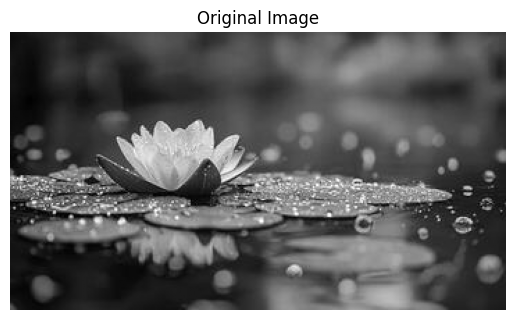

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload one image
uploaded = files.upload()
for fname in uploaded.keys():
    img = cv2.imread(fname, cv2.IMREAD_GRAYSCALE)
    break

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()


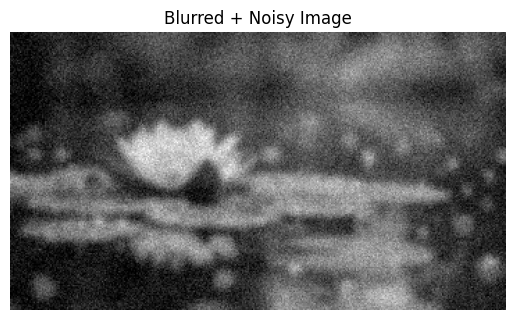

In [ ]:
# Create Gaussian blur
blurred = cv2.GaussianBlur(img, (9,9), 3)

# Add Gaussian noise
noise = np.random.normal(0, 15, img.shape)
noisy = blurred + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

# Show degraded image
plt.imshow(noisy, cmap='gray')
plt.title('Blurred + Noisy Image')
plt.axis('off')
plt.show()


In [ ]:
def inverse_filter(img, psf, eps=1e-3):
    G = np.fft.fft2(img)
    H = np.fft.fft2(psf, s=img.shape)
    H[np.abs(H) < eps] = eps
    F_hat = G / H
    f_rec = np.fft.ifft2(F_hat)
    return np.abs(f_rec)

def wiener_filter(img, psf, K=0.01):
    G = np.fft.fft2(img)
    H = np.fft.fft2(psf, s=img.shape)
    H_conj = np.conj(H)
    F_hat = (H_conj / (np.abs(H)**2 + K)) * G
    f_rec = np.fft.ifft2(F_hat)
    return np.abs(f_rec)


In [ ]:
# Small Gaussian kernel as PSF
psf = cv2.getGaussianKernel(9, 3)
psf = psf @ psf.T
psf /= psf.sum()

inv_restored = inverse_filter(noisy, psf)
wiener_restored = wiener_filter(noisy, psf, K=0.01)

# Clip and convert to uint8
inv_restored = np.clip(inv_restored, 0, 255).astype(np.uint8)
wiener_restored = np.clip(wiener_restored, 0, 255).astype(np.uint8)


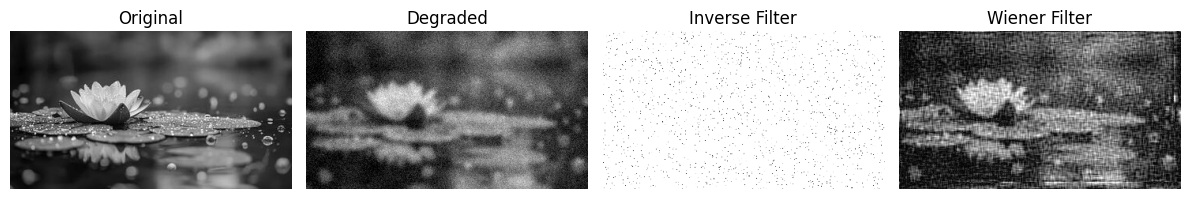

In [ ]:
plt.figure(figsize=(12,6))
titles = ['Original', 'Degraded', 'Inverse Filter', 'Wiener Filter']
images = [img, noisy, inv_restored, wiener_restored]

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


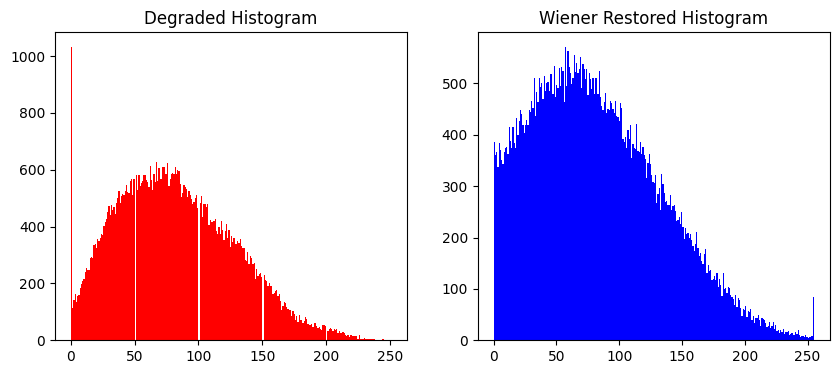

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(noisy.ravel(), bins=256, color='red')
plt.title('Degraded Histogram')

plt.subplot(1,2,2)
plt.hist(wiener_restored.ravel(), bins=256, color='blue')
plt.title('Wiener Restored Histogram')
plt.show()


In [ ]:
print("""
Observations:
1. The degraded image appears blurred and noisy.
2. The Inverse filter restores edges but amplifies noise heavily.
3. The Wiener filter gives smoother, more natural results by controlling noise amplification.
4. Hence, Wiener filtering is more stable and visually better for noisy degraded images.
""")



Observations:
1. The degraded image appears blurred and noisy.
2. The Inverse filter restores edges but amplifies noise heavily.
3. The Wiener filter gives smoother, more natural results by controlling noise amplification.
4. Hence, Wiener filtering is more stable and visually better for noisy degraded images.

